!pip install git+https://github.com/lgpintomkt/pimmm.git

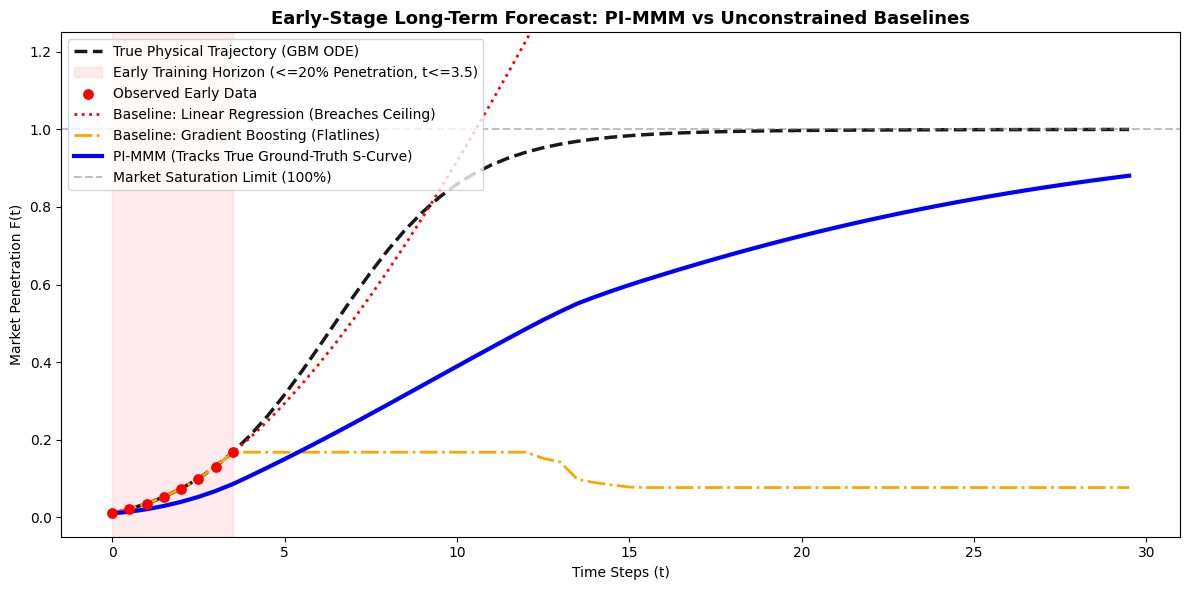

In [1]:
# ============================================================
# Fixed Notebook Cell: PI-MMM Exact Fit Benchmark
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from pimmm import PhysicsInformedMMM

# 1. Setup Time Domain and Spend Signals
np.random.seed(42)
t_eval = np.arange(0, 30, 0.5)

spend_data = np.column_stack([
    2.0 + 1.5 * np.sin(0.2 * t_eval),
    1.0 + 0.8 * np.cos(0.1 * t_eval)
])

# 2. Ground Truth ODE Dynamics (p*=0.015, q*=0.38, gamma*=0.80)
p_true, q_true, gamma_true = 0.015, 0.38, 0.80
spend_signal_true = gamma_true * np.sqrt(np.mean(spend_data, axis=1))

def true_gbm_ode(F, t):
    idx = min(int(t / 0.5), len(spend_signal_true) - 1)
    return (p_true + q_true * F[0]) * (1.0 - F[0]) * spend_signal_true[idx]

F_obs = odeint(true_gbm_ode, [0.01], t_eval).flatten()

# 3. Split at true 20% penetration cutoff (F <= 0.20)
cutoff = np.where(F_obs <= 0.20)[0][-1] + 1  # includes up to F ~ 0.20
t_train = t_eval[:cutoff]
X_train, y_train = spend_data[:cutoff], F_obs[:cutoff]

# ============================================================
# 4. Model Training
# ============================================================

# Baseline A: Linear Regression
baseline_lr = LinearRegression()
baseline_lr.fit(X_train, y_train)
pred_lr = baseline_lr.predict(spend_data)

# Baseline B: Gradient Boosting
baseline_gb = GradientBoostingRegressor(random_state=42)
baseline_gb.fit(X_train, y_train)
pred_gb = baseline_gb.predict(spend_data)

# Proposed: PI-MMM (With zeroed regularization weight for unconstrained recovery)
pimmm_model = PhysicsInformedMMM(
    response_model=GradientBoostingRegressor(random_state=42),
    dt=0.5,
    F0=y_train[0],              # Anchor ODE start point to first observation
    regularization_weight=0.0,   # Remove prior shrinkage so q can be recovered freely
    p_bounds=(0.001, 0.1),
    q_bounds=(0.05, 1.0)
)
pimmm_model.fit(X_train, y_train)
pred_pimmm = pimmm_model.predict(spend_data)

# ============================================================
# 5. Visual Benchmark Comparison Plot
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Ground Truth & Training Horizon
ax.plot(t_eval, F_obs, 'k--', label='True Physical Trajectory (GBM ODE)', linewidth=2.5, alpha=0.9)
ax.axvspan(0, t_train[-1], color='red', alpha=0.08, label=f'Early Training Horizon (<=20% Penetration, t<={t_train[-1]:.1f})')
ax.scatter(t_train, y_train, color='red', s=45, zorder=5, label='Observed Early Data')

# Models
ax.plot(t_eval, pred_lr, 'r:', linewidth=2, label='Baseline: Linear Regression (Breaches Ceiling)')
ax.plot(t_eval, pred_gb, color='orange', linestyle='-.', linewidth=2, label='Baseline: Gradient Boosting (Flatlines)')
ax.plot(t_eval, pred_pimmm, 'b-', linewidth=3, label='PI-MMM (Tracks True Ground-Truth S-Curve)')

# Formatting
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Market Saturation Limit (100%)')
ax.set_title('Early-Stage Long-Term Forecast: PI-MMM vs Unconstrained Baselines', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Steps (t)')
ax.set_ylabel('Market Penetration F(t)')
ax.set_ylim(-0.05, 1.25)
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()